In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image1 = cv2.imread(
    "./data/processed/IMG_0304.JPG"
)

image2 = cv2.imread(
    "./data/processed/IMG_0305.JPG"
)

In [3]:
def project_points(H, points):
    points = np.asarray(points, dtype=np.float64)

    points_h = np.hstack([
        points,
        np.ones((len(points), 1))
    ])

    projected_h = points_h @ H.T

    w = projected_h[:, 2]

    projected = np.full(
        (len(points), 2),
        np.nan,
        dtype=np.float64
    )

    valid = np.abs(w) > 1e-10

    projected[valid] = (
        projected_h[valid, :2]
        / w[valid, None]
    )

    return projected

def get_image_corners(image):
    h, w = image.shape[:2]

    return np.array([
        [0, 0],
        [w - 1, 0],
        [w - 1, h - 1],
        [0, h - 1]
    ], dtype=np.float64)

def neighbor_corners_in_reference(
    neighbor,
    H
):
    corners_neighbor = get_image_corners(
        neighbor
    )

    H_inv = np.linalg.inv(H)

    corners_reference = project_points(
        H_inv,
        corners_neighbor
    )

    return corners_reference

def reference_points_to_cylinder(
    points,
    focal_length,
    cx,
    cy
):
    x = points[:, 0]
    y = points[:, 1]

    theta = np.arctan2(
        x - cx,
        focal_length
    )

    y_cyl = (
        (y - cy)
        * focal_length
        / np.sqrt(
            (x - cx) ** 2
            + focal_length ** 2
        )
    )

    return theta, y_cyl

def cylindrical_bounds(
    reference,
    neighbor,
    H,
    focal_length
):
    h, w = reference.shape[:2]

    cx = (w - 1) / 2.0
    cy = (h - 1) / 2.0

    # Referência.
    ref_corners = get_image_corners(
        reference
    )

    ref_theta, ref_y = (
        reference_points_to_cylinder(
            ref_corners,
            focal_length,
            cx,
            cy
        )
    )

    # Neighbor convertida para o sistema
    # da referência.
    nei_corners_ref = (
        neighbor_corners_in_reference(
            neighbor,
            H
        )
    )

    nei_theta, nei_y = (
        reference_points_to_cylinder(
            nei_corners_ref,
            focal_length,
            cx,
            cy
        )
    )

    theta_min = min(
        ref_theta.min(),
        nei_theta.min()
    )

    theta_max = max(
        ref_theta.max(),
        nei_theta.max()
    )

    y_min = min(
        ref_y.min(),
        nei_y.min()
    )

    y_max = max(
        ref_y.max(),
        nei_y.max()
    )

    return (
        theta_min,
        theta_max,
        y_min,
        y_max
    )

def cylindrical_inverse_map(
    canvas_width,
    canvas_height,
    theta_min,
    y_min,
    focal_length,
    cx,
    cy
):
    u = np.arange(
        canvas_width,
        dtype=np.float64
    )

    v = np.arange(
        canvas_height,
        dtype=np.float64
    )

    U, V = np.meshgrid(u, v)

    # -----------------------------------------
    # Canvas -> coordenadas cilíndricas
    # -----------------------------------------

    theta = (
        theta_min
        + U / focal_length
    )

    y_cyl = (
        y_min
        + V
    )

    # -----------------------------------------
    # Cilindro -> plano perspectiva
    # -----------------------------------------

    x = (
        focal_length
        * np.tan(theta)
    )

    y = (
        cy
        + y_cyl
        * np.sqrt(
            x ** 2
            + focal_length ** 2
        )
        / focal_length
    )

    x = x + cx

    return x, y

def cylindrical_stitching(
    reference,
    neighbor,
    H,
    focal_length,
    scale=1.0
):

    # -----------------------------------------
    # 1. Redimensionar
    # -----------------------------------------

    if scale != 1.0:

        reference = cv2.resize(
            reference,
            None,
            fx=scale,
            fy=scale,
            interpolation=cv2.INTER_AREA
        )

        neighbor = cv2.resize(
            neighbor,
            None,
            fx=scale,
            fy=scale,
            interpolation=cv2.INTER_AREA
        )

        S = np.array([
            [scale, 0, 0],
            [0, scale, 0],
            [0, 0, 1]
        ], dtype=np.float64)

        H = S @ H @ np.linalg.inv(S)

    f = focal_length * scale

    h, w = reference.shape[:2]

    cx = (w - 1) / 2.0
    cy = (h - 1) / 2.0

    # -----------------------------------------
    # 2. Limites do cilindro
    # -----------------------------------------

    (
        theta_min,
        theta_max,
        y_min,
        y_max
    ) = cylindrical_bounds(
        reference,
        neighbor,
        H,
        f
    )

    # -----------------------------------------
    # 3. Canvas
    # -----------------------------------------

    canvas_width = int(
        np.ceil(
            (theta_max - theta_min) * f
        )
    )

    canvas_height = int(
        np.ceil(
            y_max - y_min
        )
    )

    print(
        "Canvas:",
        canvas_width,
        "x",
        canvas_height
    )

    # -----------------------------------------
    # 4. Canvas -> referência
    # -----------------------------------------

    map_x_ref, map_y_ref = (
        cylindrical_inverse_map(
            canvas_width,
            canvas_height,
            theta_min,
            y_min,
            f,
            cx,
            cy
        )
    )

    # -----------------------------------------
    # 5. Referência -> neighbor
    # -----------------------------------------

    points_ref = np.stack([
        map_x_ref.ravel(),
        map_y_ref.ravel()
    ], axis=1)

    points_neighbor = project_points(
        H,
        points_ref
    )

    map_x_neighbor = (
        points_neighbor[:, 0]
        .reshape(
            canvas_height,
            canvas_width
        )
    )

    map_y_neighbor = (
        points_neighbor[:, 1]
        .reshape(
            canvas_height,
            canvas_width
        )
    )

    # -----------------------------------------
    # 6. Máscaras
    # -----------------------------------------

    ref_mask = (
        np.isfinite(map_x_ref)
        & np.isfinite(map_y_ref)
        & (map_x_ref >= 0)
        & (map_x_ref < w)
        & (map_y_ref >= 0)
        & (map_y_ref < h)
    )

    hn, wn = neighbor.shape[:2]

    nei_mask = (
        np.isfinite(map_x_neighbor)
        & np.isfinite(map_y_neighbor)
        & (map_x_neighbor >= 0)
        & (map_x_neighbor < wn)
        & (map_y_neighbor >= 0)
        & (map_y_neighbor < hn)
    )

    # -----------------------------------------
    # 7. Remap
    # -----------------------------------------

    warped_reference = cv2.remap(
        reference,
        map_x_ref.astype(np.float32),
        map_y_ref.astype(np.float32),
        interpolation=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT
    )

    warped_neighbor = cv2.remap(
        neighbor,
        map_x_neighbor.astype(np.float32),
        map_y_neighbor.astype(np.float32),
        interpolation=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT
    )

    # -----------------------------------------
    # 8. Blending simples
    # -----------------------------------------

    ref_weight = ref_mask.astype(np.float32)
    nei_weight = nei_mask.astype(np.float32)

    total_weight = (
        ref_weight + nei_weight
    )

    panorama = (
        warped_reference.astype(np.float32)
        * ref_weight[..., None]
        +
        warped_neighbor.astype(np.float32)
        * nei_weight[..., None]
    )

    valid = total_weight > 0

    panorama[valid] /= (
        total_weight[valid, None]
    )

    panorama = np.clip(
        panorama,
        0,
        255
    ).astype(np.uint8)

    info = {
        "theta_min_degrees": np.degrees(
            theta_min
        ),
        "theta_max_degrees": np.degrees(
            theta_max
        ),
        "canvas_width": canvas_width,
        "canvas_height": canvas_height,
        "homography": H
    }

    return panorama, info

Detector: sift
Número de keypoints: 1004
Formato dos descritores: (1004, 128)
Número de keypoints: 1142
Formato dos descritores: (1142, 128)
Processando: imagem 0 -> imagem 1
Canvas: 1085 x 695
[{'src_index': 0, 'dst_index': 1, 'num_matches': 335, 'num_inliers': np.int64(317), 'inlier_rate': np.float64(0.9462686567164179), 'mean_reprojection_error': np.float64(0.772880859605246)}]


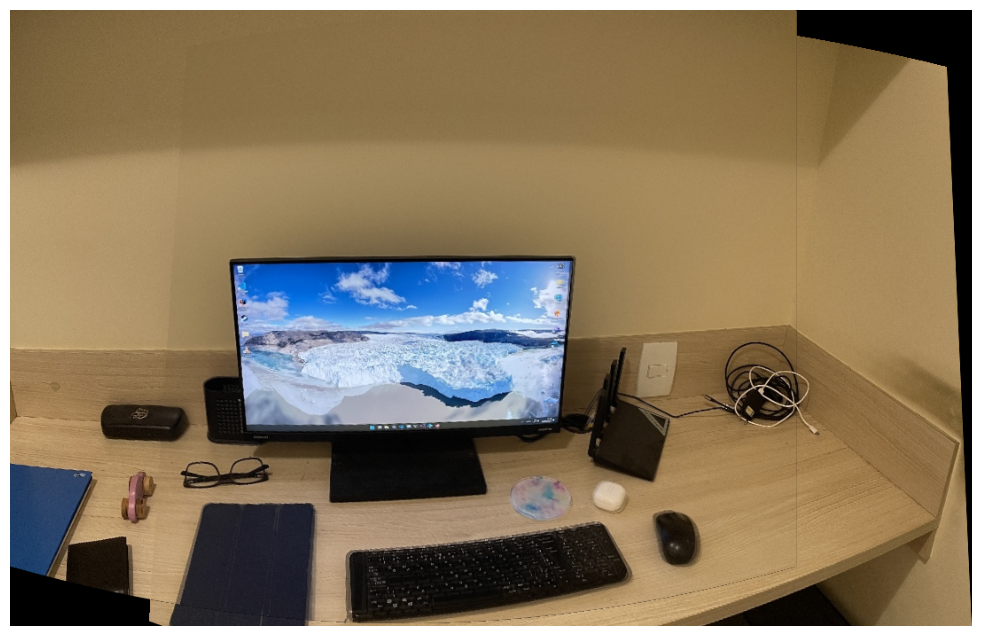

In [4]:
from src.features import draw_keypoints
from src.matching import match_all_images
from src.homography import estimate_all_homographies
from src.visualization import plot_image

images_sift = draw_keypoints([image1, image2])
matches_matrix, lowe_matrix = match_all_images([item["descriptors"] for item in images_sift], method="sift", ratio=0.7)
homographies, homography_metrics = estimate_all_homographies(lowe_matrix, [item["keypoints"] for item in images_sift], [0, 1])

panorama, info = cylindrical_stitching(image1, image2, homographies[0], 750)
print(homography_metrics)

plot_image(panorama)